# Diagnostics — four questions the headline numbers cannot answer

Analysis, not pipeline. Reads what `4a` produced and asks *why* it looks as it does; writes nothing
the chain consumes.

| | |
|---|---|
| **reads** | `outputs/panel/panel_oof_predictions.csv` — `4a`'s out-of-fold predictions |
| | `..._with_targets_auc_cc.h5ad` — labels, embeddings, Kinker's program scores |
| **writes** | `outputs/diagnostics/` — one table (and where useful one figure) per question |

Each section is a claim that was made about this pipeline, turned into something measurable.

> **Runs after `4a`.** Every table below is derived from `panel_oof_predictions.csv`, so the
> numbers are only as current as the run that wrote it.

In [1]:
import sys
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from scripts.layout import DEFAULT_CTRP_SCORE, PipelinePaths
from scripts.training.density_weighting import line_level

OUT = ROOT / 'notebooks' / 'outputs' / 'diagnostics'
OUT.mkdir(parents=True, exist_ok=True)

ACCENT, CONTEXT, INK, MUTED = '#2a78d6', '#c9c9c4', '#0b0b0b', '#52514e'
plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': MUTED, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.titlesize': 9,
    'axes.labelsize': 8, 'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'grid.color': '#e8e8e4', 'grid.linewidth': 0.6, 'font.size': 8,
})

# DEFAULT_CTRP_SCORE, not a literal: 'auc' was removed from CTRP_SCORES on 11.08.2026,
# so this line raised ValueError on construction. Named via the constant so it cannot
# go stale again when the default moves (12.08.2026).
a = ad.read_h5ad(
    PipelinePaths.build(None, 'hvg5000', DEFAULT_CTRP_SCORE).targets_h5ad, backed='r'
)
Y = np.asarray(a.obsm['Y_ctrp'], dtype=float)
M = np.asarray(a.obsm['M_ctrp'], dtype=bool)
drugs = list(a.uns['ctrp_drugs'])
groups = a.obs['Cell_line'].astype(str).to_numpy()
lines = np.unique(groups)

A, obsL = line_level(Y, M, groups, lines)   # (cell line x drug) raw auc + observation mask
A = pd.DataFrame(np.where(obsL, A, np.nan), index=lines, columns=drugs)
print(f'{A.shape[0]} cell lines x {A.shape[1]} drugs | labelled lines: {int(A.notna().any(axis=1).sum())}')

198 cell lines x 534 drugs | labelled lines: 181


## 1 · The drug-selection gate filtered on potency, not on rankability

| | |
|---|---|
| **out** | `gate_per_drug.csv`, `gate_potency_vs_spread.png` |

The retired gate scored a drug by `min(#killed, #spared)` — how many lines fall on each side of a
viability threshold. That is a statement about where a compound's responses sit on the scale, not
about whether they can be *ordered*.

**Why it matters beyond the gate.** A compound can have a wide, well-ordered response range and still
score badly if its values happen to sit mostly on one side of the cut, and a compound with a narrow
range straddling the cut scores well. The plot puts potency on one axis and spread on the other, so
the two are visibly not the same quantity.

In [2]:
KILL, SPARE, COV_MIN, STD_MIN = 0.5, 0.8, 0.90, 0.10
n_lines_total = int(A.notna().any(axis=1).sum())

gate = pd.DataFrame({
    'n_lines': A.notna().sum(axis=0),
    'auc_mean': A.mean(axis=0),
    'auc_std': A.std(axis=0, ddof=0),
    'kills': (A <= KILL).sum(axis=0),
    'spares': (A >= SPARE).sum(axis=0),
})
gate['cov_frac'] = gate['n_lines'] / n_lines_total

print('the comparison that exposed it:')
print(gate.loc[['dasatinib', 'nutlin-3'], ['auc_mean', 'auc_std', 'kills', 'spares']].round(3).to_string())

discarded = gate[(gate.kills == 0) & (gate.auc_std >= STD_MIN) & (gate.cov_frac >= COV_MIN)]
print(f'\ndrugs with ZERO kills but auc_std >= {STD_MIN} and coverage >= {COV_MIN:.0%}: '
      f'{len(discarded)} of {len(gate)}')
print('   widest of them:', ', '.join(discarded.sort_values('auc_std', ascending=False)
                                      .head(6).index.tolist()))
gate.round(3).to_csv(OUT / 'gate_per_drug.csv')

the comparison that exposed it:
           auc_mean  auc_std  kills  spares
dasatinib     0.674    0.169     21      47
nutlin-3      0.897    0.078      0     151

drugs with ZERO kills but auc_std >= 0.1 and coverage >= 90%: 51 of 534
   widest of them: pi-103, gmx-1778, decitabine-navitoclax (2-1 mol-mol), erlotinib, tretinoin-navitoclax (4-1 mol-mol), epigallocatechin-3-monogallate


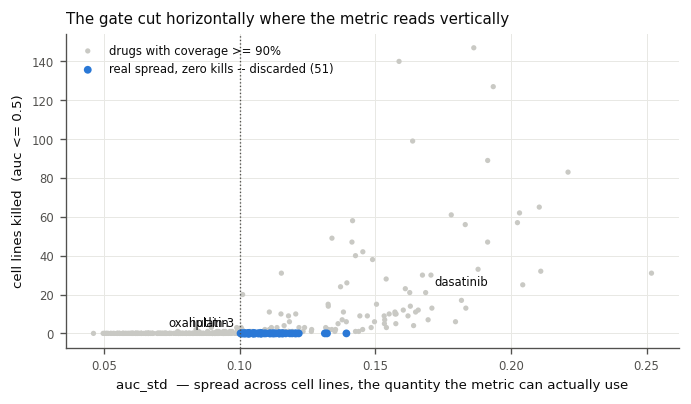

In [3]:
fig, ax = plt.subplots(figsize=(6.6, 3.4))
keep = gate.cov_frac >= COV_MIN
ax.scatter(gate.loc[keep, 'auc_std'], gate.loc[keep, 'kills'], s=10, color=CONTEXT,
           edgecolors='none', label=f'drugs with coverage >= {COV_MIN:.0%}')
ax.scatter(discarded['auc_std'], discarded['kills'], s=22, color=ACCENT, edgecolors='none',
           label=f'real spread, zero kills -- discarded ({len(discarded)})')
for d in ['nutlin-3', 'dasatinib', 'oxaliplatin']:
    if d in gate.index:
        ax.annotate(d, (gate.loc[d, 'auc_std'], gate.loc[d, 'kills']),
                    textcoords='offset points', xytext=(5, 4), fontsize=7, color=INK)
ax.axvline(STD_MIN, color=MUTED, linewidth=0.8, linestyle=':')
ax.set_xlabel('auc_std  — spread across cell lines, the quantity the metric can actually use')
ax.set_ylabel('cell lines killed  (auc <= 0.5)')
ax.set_title('The gate cut horizontally where the metric reads vertically', loc='left', color=INK)
ax.grid(True)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=7, loc='upper left')
fig.savefig(OUT / 'gate_potency_vs_spread.png')
plt.show()

## 2 · The per-cell loss weights cell lines by sequencing depth

| | |
|---|---|
| **out** | `loss_share_per_line.csv`, `loss_share_per_line.png` |

The per-cell objective sums over cells, and a line contributes as many terms as it has cells — 56 for
the smallest, 1,990 for the largest. A line therefore enters the loss in proportion to how deeply it
was sequenced, which is a property of the experiment rather than of the biology.

**Why this is measured rather than argued.** The share is computable directly: each line's fraction
of the total loss terms. It is also the defect complete-bag MIL removes structurally, since one bag
is one line is one training example — so this table is the reference `4b` is read against.

In [4]:
cells = pd.Series(groups).value_counts()
labelled = A.notna().any(axis=1)
w = pd.DataFrame({'cells': cells.reindex(A.index), 'drugs': A.notna().sum(axis=1)})[labelled]
w['loss_share'] = (w.cells * w.drugs) / (w.cells * w.drugs).sum()
w = w.sort_values('loss_share', ascending=False)
fair = 1 / len(w)

print(f'{len(w)} labelled cell lines')
print(f'  cells per line : {w.cells.min()} .. {w.cells.max()}  (median {int(w.cells.median())}) '
      f'-> {w.cells.max() / w.cells.min():.0f}x')
print(f'  drugs per line : {w.drugs.min()} .. {w.drugs.max()}  (median {int(w.drugs.median())}) '
      f'-> {w.drugs.max() / w.drugs.min():.0f}x')
print(f'  loss share     : {w.loss_share.iloc[0]:.2%} ({w.index[0]}) down to '
      f'{w.loss_share.iloc[-1]:.3%} ({w.index[-1]}) -> {w.loss_share.iloc[0] / w.loss_share.iloc[-1]:.0f}x')
print(f'  equal shares would be {fair:.2%} each; the top 10 lines carry '
      f'{w.loss_share.head(10).sum():.1%} instead of {10 * fair:.1%}')
w.round(6).to_csv(OUT / 'loss_share_per_line.csv')

181 labelled cell lines
  cells per line : 56 .. 1990  (median 226) -> 36x
  drugs per line : 38 .. 502  (median 464) -> 13x
  loss share     : 4.34% (NCIH2110_LUNG) down to 0.053% (PANC1_PANCREAS) -> 82x
  equal shares would be 0.55% each; the top 10 lines carry 18.2% instead of 5.5%


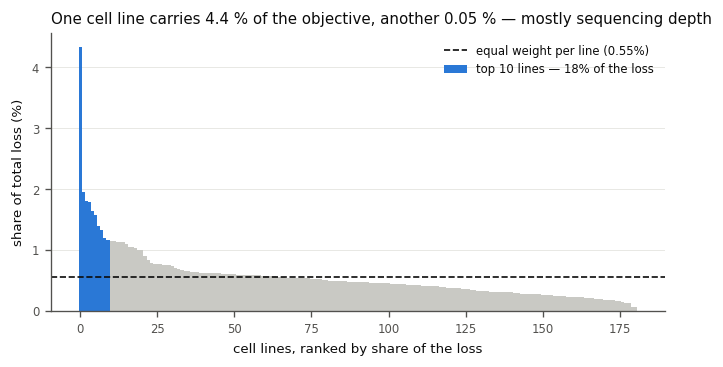

In [5]:
fig, ax = plt.subplots(figsize=(6.6, 3.0))
x = np.arange(len(w))
ax.bar(x, w.loss_share.values * 100, width=1.0, color=CONTEXT, edgecolor='none')
top = 10
ax.bar(x[:top], w.loss_share.values[:top] * 100, width=1.0, color=ACCENT, edgecolor='none',
       label=f'top {top} lines — {w.loss_share.head(top).sum():.0%} of the loss')
ax.axhline(fair * 100, color=INK, linewidth=1.0, linestyle='--',
           label=f'equal weight per line ({fair:.2%})')
ax.set_xlabel('cell lines, ranked by share of the loss')
ax.set_ylabel('share of total loss (%)')
ax.set_title('One cell line carries 4.4 % of the objective, another 0.05 % — mostly sequencing depth',
             loc='left', color=INK)
ax.grid(axis='y')
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=7)
fig.savefig(OUT / 'loss_share_per_line.png')
plt.show()

## 3 · The cell-line effect is not proliferation

| | |
|---|---|
| **out** | `line_effect_vs_programs.csv`, `line_effect_vs_proliferation.png` |

Some cell lines are broadly sensitive to everything, and that line effect carries much of the
predictable signal. The claim under test is that it is largely proliferation — fast-growing lines
dying more readily.

**How it is tested.** Correlate each line's mean response across drugs against its cell-cycle score,
and against every other annotated Kinker program, so proliferation is not privileged by being the
only thing looked at. A refutation needs the alternatives on the same axis.

In [6]:
Z = (A - A.mean(axis=0)) / A.std(axis=0, ddof=0)   # per-drug z across lines
line_effect = Z.mean(axis=1, skipna=True).dropna()

PROGRAMS = ['G1/S_score', 'G2/M_score', 'EMTI_score', 'EMTII_score', 'EMTIII_score', 'IFNResp_score',
            'p53Sen_score', 'EpiSen_score', 'StressResp_score', 'ProtMatu_score', 'ProtDegra_score',
            'SkinPig_score']
prog = pd.DataFrame({c: pd.to_numeric(a.obs[c].values, errors='coerce') for c in PROGRAMS})
prog['line'] = groups
per_line = prog.groupby('line').mean(numeric_only=True)
per_line['proliferation'] = per_line[['G1/S_score', 'G2/M_score']].mean(axis=1)

print('--- control 1: does the cell-line effect have real spread? ---')
print(f'   mean {line_effect.mean():+.3f}  std {line_effect.std():.3f}  '
      f'range {line_effect.min():+.2f} .. {line_effect.max():+.2f}   (z units)')
print('--- control 2: do the scores vary between lines, not just within? ---')
for c in ['G1/S_score', 'G2/M_score']:
    s = pd.Series(prog[c].values, index=groups)
    b, wi = s.groupby(level=0).mean().std(), s.groupby(level=0).std().mean()
    print(f'   {c:12s} between-line std {b:.3f} vs mean within-line std {wi:.3f}  (ratio {b / wi:.2f})')

rows = []
for c in PROGRAMS + ['proliferation']:
    j = per_line[c].reindex(line_effect.index)
    ok = j.notna()
    r, p = spearmanr(j[ok], line_effect[ok])
    rows.append({'program': c, 'rho': r, 'p': p, 'n': int(ok.sum())})
res = pd.DataFrame(rows).sort_values('rho', key=abs, ascending=False).set_index('program')
res.to_csv(OUT / 'line_effect_vs_programs.csv')
print(f'\nSpearman vs the cell-line effect (n = {res["n"].iloc[0]} lines):')
print(res.round(3).to_string())

--- control 1: does the cell-line effect have real spread? ---
   mean -0.010  std 0.402  range -2.13 .. +1.01   (z units)
--- control 2: do the scores vary between lines, not just within? ---


   G1/S_score   between-line std 0.233 vs mean within-line std 0.593  (ratio 0.39)
   G2/M_score   between-line std 0.254 vs mean within-line std 0.803  (ratio 0.32)

Spearman vs the cell-line effect (n = 181 lines):
                    rho      p    n
program                            
ProtDegra_score  -0.190  0.010  181
ProtMatu_score   -0.161  0.031  181
p53Sen_score      0.053  0.476  181
G1/S_score       -0.051  0.496  181
EpiSen_score      0.051  0.496  181
EMTI_score        0.050  0.505  181
StressResp_score -0.038  0.615  181
proliferation    -0.034  0.652  181
IFNResp_score    -0.029  0.697  181
G2/M_score       -0.022  0.771  181
EMTII_score       0.008  0.917  181
EMTIII_score      0.008  0.917  181
SkinPig_score    -0.007  0.929  181


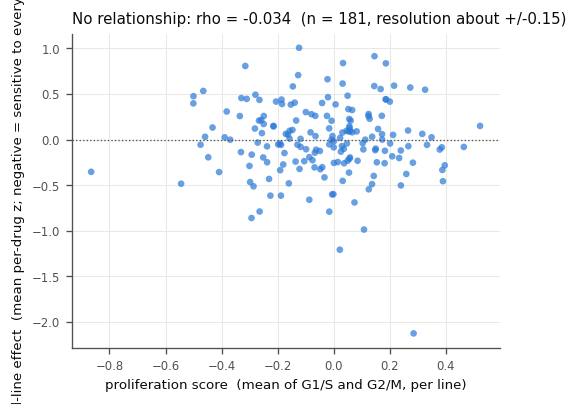

The effect is large and real, and none of the twelve published programs of this dataset
explains it. Removing it therefore discards no biology we would want to keep.


In [7]:
j = per_line['proliferation'].reindex(line_effect.index)
r = res.loc['proliferation', 'rho']
ci = 1.96 / np.sqrt(len(line_effect) - 3)   # Fisher-z half-width, ~the resolution of this test

fig, ax = plt.subplots(figsize=(4.6, 3.4))
ax.scatter(j, line_effect, s=16, color=ACCENT, edgecolors='none', alpha=0.7)
ax.axhline(0, color=MUTED, linewidth=0.8, linestyle=':')
ax.set_xlabel('proliferation score  (mean of G1/S and G2/M, per line)')
ax.set_ylabel('cell-line effect  (mean per-drug z; negative = sensitive to everything)')
ax.set_title(f'No relationship: rho = {r:+.3f}  (n = {len(line_effect)}, resolution about +/-{ci:.2f})',
             loc='left', color=INK)
ax.grid(True)
ax.set_axisbelow(True)
fig.savefig(OUT / 'line_effect_vs_proliferation.png')
plt.show()
print('The effect is large and real, and none of the twelve published programs of this dataset')
print('explains it. Removing it therefore discards no biology we would want to keep.')

## 4 · The two representations enter the network on different scales

| | |
|---|---|
| **out** | `input_scale.csv` |

`X_pca` and `X_scGPT` are both 512-dimensional, but nothing makes their *magnitudes* comparable: PCA
coordinates carry the variance of the data, scGPT's are the output of a trained encoder.

**Why it matters under one shared learning rate.** Both arms use the same trunk, the same optimiser
and the same step size, so a systematic scale difference means the two arms are not receiving
equivalent updates — and any measured difference between representations partly reflects that rather
than the information they carry.

In [8]:
rows = []
for rep in ['X_pca', 'X_scGPT']:
    X = np.asarray(a.obsm[rep], dtype=np.float64)
    sd = X.std(axis=0)
    rows.append({'rep': rep, 'dims': X.shape[1], 'std_median': np.median(sd),
                 'std_max': sd.max(), 'std_min': sd.min(),
                 'within_rep_ratio': sd.max() / sd.min(), 'abs_mean_magnitude': np.abs(X).mean()})
scale = pd.DataFrame(rows).set_index('rep')
scale.to_csv(OUT / 'input_scale.csv')
print(scale.round(4).to_string())
print(f'\nbetween-representation ratio of median per-dimension std: '
      f'{scale.loc["X_pca", "std_median"] / scale.loc["X_scGPT", "std_median"]:.0f}x')
print('within-representation conditioning is comparable '
      f'({scale.loc["X_pca", "within_rep_ratio"]:.0f}x vs '
      f'{scale.loc["X_scGPT", "within_rep_ratio"]:.0f}x) -- the asymmetry is absolute magnitude')

         dims  std_median  std_max  std_min  within_rep_ratio  abs_mean_magnitude
rep                                                                              
X_pca     512      1.1062   9.5979   1.0218            9.3927              1.1404
X_scGPT   512      0.0107   0.0258   0.0046            5.6107              0.0249

between-representation ratio of median per-dimension std: 104x
within-representation conditioning is comparable (9x vs 6x) -- the asymmetry is absolute magnitude


## 5 · How much do the results move?

| | |
|---|---|
| **out** | `result_dispersion.csv` |

Two dispersions, answering different questions. **Across folds:** how much does the number depend on
which cell lines were held out? **Across seeds:** how much does it depend on initialisation?

**Why they must not be pooled.** Fold spread confounds fold difficulty with model instability — a
fold holding out harder lines scores worse for a reason that has nothing to do with the model. Seed
spread isolates instability. A single error bar over both would be neither.

In [9]:
from scripts.training.cv import grouped_folds

# ROOT-anchored, like OUT above (fixed 13.08.2026, Gate 5). This was a bare
# Path('outputs')/..., which resolves against the KERNEL's working directory -- and nbconvert
# runs a notebook from its own directory, so it pointed at
# notebooks/analysis/evaluation/outputs/ and raised FileNotFoundError. It only ever worked
# when the notebook was launched by hand from notebooks/.
oof = pd.read_csv(ROOT / 'notebooks' / 'outputs' / 'panel' / 'panel_oof_predictions.csv')
idx, folds = grouped_folds(a, n_splits=5)
line_fold = {ln: f for f, (_, va) in enumerate(folds, 1)
             for ln in np.unique(groups[idx[va]])}
oof['fold'] = oof.cell_line.map(line_fold)


def rho_per_drug(df):
    return df.groupby('drug').apply(
        lambda d: spearmanr(d.y_pred, d.y_true).statistic if len(d) > 5 else np.nan,
        include_groups=False)


rows = []
for (rep, alpha), g in oof.groupby(['rep', 'alpha']):
    pooled = rho_per_drug(g)                                  # one correlation per drug, ~150 lines
    per_fold = np.array([np.nanmean(rho_per_drug(gf)) for _, gf in g.groupby('fold')])
    rows.append({'rep': rep, 'alpha': alpha,
                 'pooled_mean': pooled.mean(), 'sd_across_drugs': pooled.std(ddof=1),
                 'drug_min': pooled.min(), 'drug_max': pooled.max(),
                 'foldwise_mean': per_fold.mean(), 'sd_across_folds': per_fold.std(ddof=1)})
disp = pd.DataFrame(rows).set_index(['rep', 'alpha']).round(3)
disp.to_csv(OUT / 'result_dispersion.csv')
print(disp.to_string())

# alpha=0.0 is the unweighted arm -- what `xs(False)` used to select. Renamed 13.08.2026; this
# notebook reads the LIVE panel_oof_predictions.csv, so it moves with the writer rather than
# being frozen like make_figures' legacy panels.
u = disp.xs(0.0, level='alpha')
gap = u.loc['X_scGPT', 'pooled_mean'] - u.loc['X_pca', 'pooled_mean']
print(f"\nscGPT - PCA = {gap:+.3f}, against a fold-to-fold sd of "
      f"{u.loc['X_pca', 'sd_across_folds']:.3f} (PCA) and {u.loc['X_scGPT', 'sd_across_folds']:.3f} (scGPT)")
print('-> the gap is about the size of one fold standard deviation. Consistent, not established.')

               pooled_mean  sd_across_drugs  drug_min  drug_max  foldwise_mean  sd_across_folds
rep     alpha                                                                                  
X_pca   0.0          0.223            0.196    -0.044     0.514          0.273            0.039
        0.5          0.266            0.141     0.081     0.509          0.286            0.029
        1.0          0.254            0.147     0.062     0.502          0.284            0.053
X_scGPT 0.0          0.195            0.180    -0.052     0.494          0.238            0.057
        0.5          0.190            0.195    -0.140     0.500          0.211            0.030
        1.0          0.189            0.172    -0.069     0.484          0.228            0.024

scGPT - PCA = -0.028, against a fold-to-fold sd of 0.039 (PCA) and 0.057 (scGPT)
-> the gap is about the size of one fold standard deviation. Consistent, not established.


## Summary

What each section establishes, and what it does not. None of these is a result about model
performance: they are properties of the objective, the data and the evaluation that a headline number
cannot show — which is why they live outside the chain and are read alongside it rather than in it.